In [59]:
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')



df = pd.read_excel('/content/drive/MyDrive/student_math.xlsx')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [60]:
df.shape

(395, 34)

In [61]:
df.head()

,student_id,school,sex,age,address_type,family_size,parent_status,mother_education,father_education,mother_job,...,family_relationship,free_time,social,weekday_alcohol,weekend_alcohol,health,absences,grade_1,grade_2,final_grade
0,1,GP,F,18,Urban,Greater than 3,Apart,higher education,higher education,at_home,...,4,3,4,1,1,3,6,5,6,6
1,2,GP,F,17,Urban,Greater than 3,Living together,primary education (4th grade),primary education (4th grade),at_home,...,5,3,3,1,1,3,4,5,5,6
2,3,GP,F,15,Urban,Less than or equal to 3,Living together,primary education (4th grade),primary education (4th grade),at_home,...,4,3,2,2,3,3,10,7,8,10
3,4,GP,F,15,Urban,Greater than 3,Living together,higher education,5th to 9th grade,health,...,3,2,2,1,1,5,2,15,14,15
4,5,GP,F,16,Urban,Greater than 3,Living together,secondary education,secondary education,other,...,4,3,2,1,2,5,4,6,10,10


In [62]:
df.columns

Index(['student_id', 'school', 'sex', 'age', 'address_type', 'family_size',
       'parent_status', 'mother_education', 'father_education', 'mother_job',
       'father_job', 'school_choice_reason', 'guardian', 'travel_time',
       'study_time', 'class_failures', 'school_support', 'family_support',
       'extra_paid_classes', 'activities', 'nursery_school', 'higher_ed',
       'internet_access', 'romantic_relationship', 'family_relationship',
       'free_time', 'social', 'weekday_alcohol', 'weekend_alcohol', 'health',
       'absences', 'grade_1', 'grade_2', 'final_grade'],
      dtype='object')

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   student_id             395 non-null    int64 
 1   school                 395 non-null    object
 2   sex                    395 non-null    object
 3   age                    395 non-null    int64 
 4   address_type           395 non-null    object
 5   family_size            395 non-null    object
 6   parent_status          395 non-null    object
 7   mother_education       395 non-null    object
 8   father_education       395 non-null    object
 9   mother_job             395 non-null    object
 10  father_job             395 non-null    object
 11  school_choice_reason   395 non-null    object
 12  guardian               395 non-null    object
 13  travel_time            395 non-null    object
 14  study_time             395 non-null    object
 15  class_failures         

In [64]:
df.isnull().sum()



,0
student_id,0
school,0
sex,0
age,0
address_type,0
family_size,0
parent_status,0
mother_education,0
father_education,0
mother_job,0


In [65]:
categorical = df.select_dtypes(include=['object'])
numeric = df.select_dtypes(include=['int64'])

categorical.columns, numeric.columns


(Index(['school', 'sex', 'address_type', 'family_size', 'parent_status',
        'mother_education', 'father_education', 'mother_job', 'father_job',
        'school_choice_reason', 'guardian', 'travel_time', 'study_time',
        'school_support', 'family_support', 'extra_paid_classes', 'activities',
        'nursery_school', 'higher_ed', 'internet_access',
        'romantic_relationship'],
       dtype='object'),
 Index(['student_id', 'age', 'class_failures', 'family_relationship',
        'free_time', 'social', 'weekday_alcohol', 'weekend_alcohol', 'health',
        'absences', 'grade_1', 'grade_2', 'final_grade'],
       dtype='object'))

In [66]:
for col in categorical.columns:
    print(f"{col}:\n{df[col].value_counts()}\n")


school:
school
GP    349
MS     46
Name: count, dtype: int64

sex:
sex
F    208
M    187
Name: count, dtype: int64

address_type:
address_type
Urban    307
Rural     88
Name: count, dtype: int64

family_size:
family_size
Greater than 3             281
Less than or equal to 3    114
Name: count, dtype: int64

parent_status:
parent_status
Living together    354
Apart               41
Name: count, dtype: int64

mother_education:
mother_education
higher education                 131
5th to 9th grade                 103
secondary education               99
primary education (4th grade)     59
none                               3
Name: count, dtype: int64

father_education:
father_education
5th to 9th grade                 115
secondary education              100
higher education                  96
primary education (4th grade)     82
none                               2
Name: count, dtype: int64

mother_job:
mother_job
other       141
services    103
at_home      59
teacher      58
health 

In [67]:
numeric_cols = [ 'age', 'class_failures', 'family_relationship',
                 'free_time', 'social', 'weekday_alcohol', 'weekend_alcohol',
                 'health', 'absences', 'grade_1', 'grade_2']

bin_no_yesno  = ['school', 'sex', 'address_type', 'family_size','parent_status']

bin_yesno =  ['school_support', 'family_support', 'extra_paid_classes', 'activities','nursery_school', 'higher_ed',  'internet_access', 'romantic_relationship']

cat_no_binary = [ 'mother_education', 'father_education', 'mother_job', 'father_job', 'school_choice_reason', 'guardian', 'travel_time', 'study_time']


In [ ]:
numeric_df = df[numeric_cols]
no_binary_df = pd.get_dummies(df[cat_no_binary],drop_first=True, dtype='float')
binary_map = {'yes': 1, 'no': 0}
yesno_df = df[bin_yesno].replace(binary_map)

In [73]:
no_binary_df

,mother_education_higher education,mother_education_none,mother_education_primary education (4th grade),mother_education_secondary education,father_education_higher education,father_education_none,father_education_primary education (4th grade),father_education_secondary education,mother_job_health,mother_job_other,...,school_choice_reason_other,school_choice_reason_reputation,guardian_mother,guardian_other,travel_time_30 min. to 1 hour,travel_time_<15 min.,travel_time_>1 hour,study_time_5 to 10 hours,study_time_<2 hours,study_time_>10 hours
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
391,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
392,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
393,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [69]:
df['school'] = df['school'].map({'GP': 1, 'MS': 0})
df['sex']=df['sex'].map({'F': 1, 'M':0 })
df['address_type']=df['address_type'].map({'Urban':0 , 'Rural':1})
df['family_size']=df['family_size'].map({'Less than or equal to 3':0 , 'Greater than 3':1})
df['parent_status']=df['parent_status'].map({'Apart':0 , 'Living together':1})

binary_column_df=df[['school','sex','address_type', 'family_size','parent_status']]

In [75]:
X = pd.concat([numeric_df,  no_binary_df,yesno_df,binary_column_df], axis=1)

y=df['final_grade']

In [76]:
X

,age,class_failures,family_relationship,free_time,social,weekday_alcohol,weekend_alcohol,health,absences,grade_1,...,activities,nursery_school,higher_ed,internet_access,romantic_relationship,school,sex,address_type,family_size,parent_status
0,18,0,4,3,4,1,1,3,6,5,...,0,1,1,0,0,1,1,0,1,0
1,17,0,5,3,3,1,1,3,4,5,...,0,0,1,1,0,1,1,0,1,1
2,15,3,4,3,2,2,3,3,10,7,...,0,1,1,1,0,1,1,0,0,1
3,15,0,3,2,2,1,1,5,2,15,...,1,1,1,1,1,1,1,0,1,1
4,16,0,4,3,2,1,2,5,4,6,...,0,1,1,0,0,1,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,20,2,5,5,4,4,5,4,11,9,...,0,1,1,0,0,0,0,0,0,0
391,17,0,2,4,5,3,4,2,3,14,...,0,0,1,1,0,0,0,0,0,1
392,21,3,5,5,3,3,3,3,3,10,...,0,0,1,0,0,0,0,1,1,1
393,18,0,4,4,1,3,4,5,0,11,...,0,0,1,1,0,0,0,1,0,1


In [78]:
X_train , X_test, y_train, y_test=train_test_split(X,y,test_size=0.2)

In [79]:
model=LinearRegression()
model.fit(X_train,y_train)
prediction = model.predict(X_test)

In [81]:
mae=mean_absolute_error(y_test,prediction)
r2=r2_score(y_test,prediction)
mse=mean_squared_error(y_test,prediction)

print(f"Mean absolute error = {mae}")
print(f"R² score = {r2}")

print(f"Mean squared error = {mse}")
rmse = mse ** 0.5
print(f"Root mean squared error = {rmse}")

Mean absolute error = 1.2928423313850141
R² score = 0.8525802132590786
Mean squared error = 3.0407545500975495
Root mean squared error = 1.7437759460714986


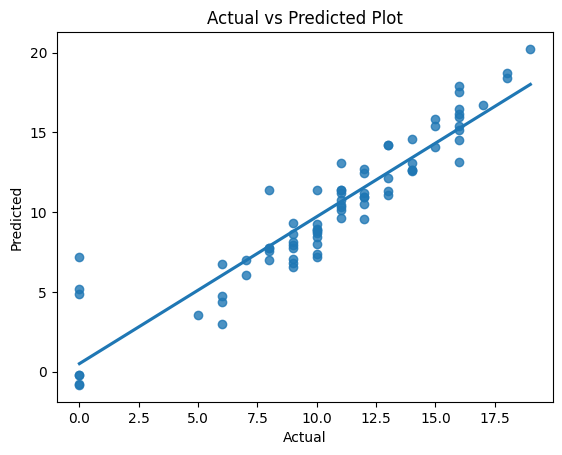

In [82]:
plot_df = pd.DataFrame({'Actual': y_test,'Predicted': prediction})

sns.regplot(data=plot_df,x='Actual',y='Predicted',ci=None)
plt.title('Actual vs Predicted Plot')
plt.show()

Text(0.5, 1.0, 'Residuals vs. Fitted values plot')

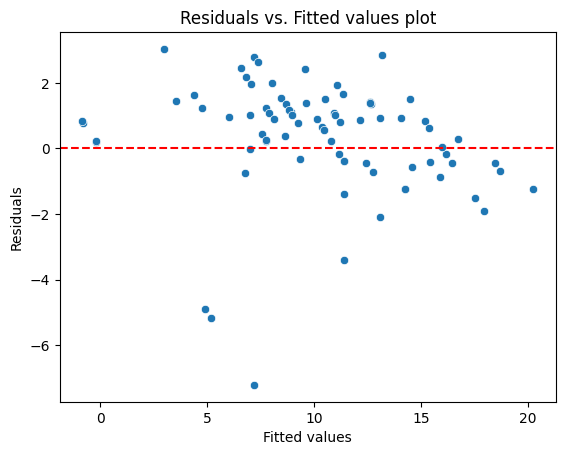

In [83]:
errors = y_test - prediction
sns.scatterplot(x=prediction, y=errors)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted values plot")
#also check if this is correct.


Text(0, 0.5, 'Actual Quantiles (Residuals)')

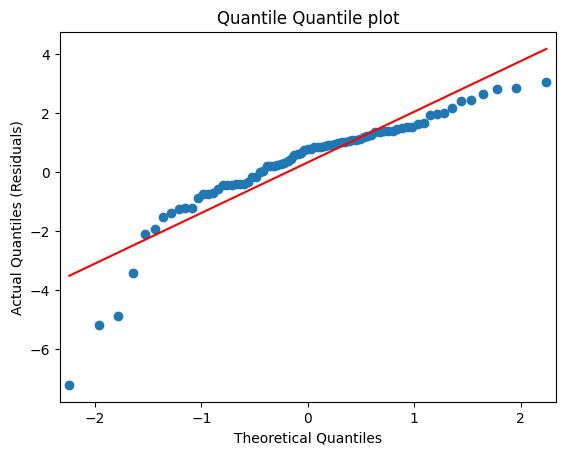

In [84]:
sm.qqplot(errors, line='s')
plt.title("Quantile Quantile plot")
plt.ylabel("Actual Quantiles (Residuals)")
#check  if this is correct,I am 99% sure it is.But still check it.-Harikesh


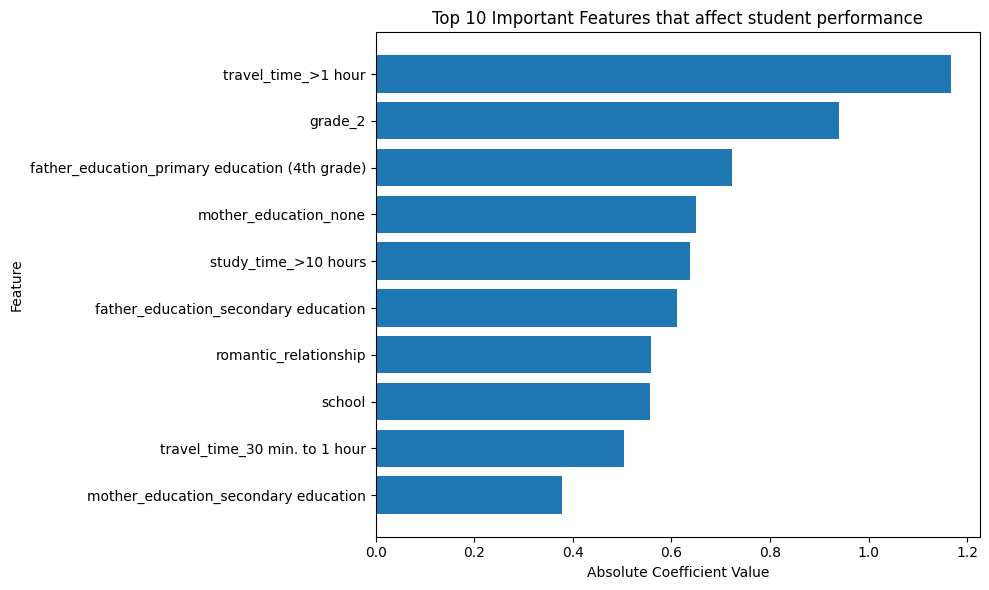

In [85]:
importance=pd.DataFrame({
    "feature": X.columns,
    "coefficient":model.coef_
})
importance["importance"]=importance["coefficient"].abs()
importance = importance.sort_values(
    by="importance",
    ascending=False
)
importance

top_n =10

top_features = importance.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features["feature"],
    top_features["importance"]
)
plt.gca().invert_yaxis()
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature")
plt.title(f"Top {top_n} Important Features that affect student performance")
plt.tight_layout()
plt.show()
